# RouteZone — Notebook 07 : Modélisation V3 (OSRM)

---

| | |
|---|---|
| **Candidate** | Meriem Abdelouahed |
| **Formation** | Développeur en Intelligence Artificielle — Simplon x Microsoft |
| **Certification** | RNCP37827 |
| **Projet** | RouteZone — Prédiction de gravité des accidents routiers |
| **Notebook** | 07 / 08 — Modélisation V3 : remplacement Haversine par OSRM réel |

---

## Sommaire

1. [Imports et configuration](#1-imports)
2. [Préparation des données — features V3 OSRM](#2-donnees)
3. [Entraînement V3 (mêmes hyperparamètres que V2)](#3-entrainement)
4. [Comparaison V2 (Haversine) vs V3 (OSRM)](#4-comparaison)
5. [Explicabilité — Feature Importance et SHAP](#5-shap)
6. [Calibration et sauvegarde](#6-calibration)
7. [Conclusion](#7-conclusion)

---

## Objectif et différences avec la V2

Le notebook 06 (V2) a enrichi le modèle avec **9 nouvelles features** dont les temps Haversine
(distance vol d'oiseau × 1.3 à 60 km/h). Cette approximation a deux limites majeures :

- Elle **ignore les routes réelles** : un trajet à vol d'oiseau n'existe pas en montagne, en zone urbaine dense, ou autour des fleuves
- Elle **suppose une vitesse constante** de 60 km/h, ce qui ne reflète ni les autoroutes (~110 km/h) ni les zones urbaines (~30 km/h)

**Ce notebook remplace les temps Haversine par des temps OSRM réels :**

| | V2 (notebook 06) | V3 (ce notebook) |
|---|---|---|
| Calcul des temps | Haversine × 1.3 / 60 km/h | **OSRM** (moteur de routage routier réel) |
| Routes prises en compte | ❌ vol d'oiseau | ✅ **routes réelles** (autoroutes, départementales, urbain) |
| Vitesses | Constante 60 km/h | **Variables** selon le type de route |
| Source des temps | Calcul mathématique | **Open Source Routing Machine** (basé OpenStreetMap) |
| Features | 34 | **34** (mêmes, sauf 2 colonnes remplacées) |
| Hyperparamètres | Configuration figée | **Configuration figée identique** |

**L'optimisation des hyperparamètres (Optuna, GridSearch) est réservée au notebook 08.**
On garde ici les **mêmes hyperparamètres que le notebook 06** pour que la comparaison V2 vs V3
isole **uniquement** l'effet du changement de feature (OSRM vs Haversine).

---

### Rappel — Qu'est-ce qu'OSRM ?

**OSRM** (Open Source Routing Machine) est un moteur de calcul d'itinéraires open source basé sur
les données OpenStreetMap. C'est le même type de moteur que celui qui fait fonctionner Mapbox
ou les directions sur les sites de SAMU.

```
distance routière réelle (km) × profil de vitesse → temps en minutes
```

Pour ce projet, OSRM a été lancé via Docker avec les cartes de France métropolitaine.
Le batch `src/scripts/enrich_osrm_batch.py` a calculé les temps **caserne → accident → hôpital**
pour chaque accident géolocalisé du dataset, région par région.

Le résultat est dans `data/processed/temps_intervention_osrm.csv` — c'est ce fichier qu'on
charge ici.

**Compétences couvertes :** C8 (service IA), C9 (API IA)


<a id='1-imports'></a>
## 1. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from datetime import datetime

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    f1_score, recall_score, precision_score
)
from sklearn.calibration import CalibratedClassifierCV
import lightgbm as lgb
import mlflow
import mlflow.sklearn

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

_cwd = Path.cwd()
ROOT = _cwd if (_cwd / "data" / "processed").exists() else _cwd.parent
DATA_PATH = ROOT / "data" / "processed" / "dataset_clean.csv"
INTERV_OSRM_PATH = ROOT / "data" / "processed" / "temps_intervention_osrm.csv"
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
VIZ_DIR = Path("visualisations")
VIZ_DIR.mkdir(exist_ok=True)

mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment("routezone_v3_osrm")

# Pre-requis : avoir tourne `python src/scripts/enrich_osrm_batch.py --regions all`
assert INTERV_OSRM_PATH.exists(), (
    f"Manquant : {INTERV_OSRM_PATH}\n"
    "Lance d'abord : python src/scripts/enrich_osrm_batch.py --regions all"
)
print("Imports OK")


C:\Users\Utilisateur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


> **Observation :**
> Les imports sont quasi-identiques au notebook 06 — on garde la même base technique :
> - `lightgbm` pour le modèle
> - `mlflow` pour le tracking d'expériences
> - `CalibratedClassifierCV` pour calibrer les probabilités
>
> **Différences avec le notebook 06 :**
> - On charge `temps_intervention_osrm.csv` au lieu de `temps_intervention.csv` (Haversine)
> - L'experiment MLflow s'appelle `routezone_v3_osrm` (séparation propre des runs)
>
> **Pré-requis avant de lancer ce notebook :**
> Il faut avoir tourné `python src/scripts/enrich_osrm_batch.py --regions all` en amont pour
> générer le fichier OSRM (sinon l'assertion en fin de cellule lève une erreur claire).
> Le batch OSRM prend plusieurs heures car il fait ~400 000 requêtes API au serveur Docker.


<a id='2-donnees'></a>
## 2. Préparation des données — features V3 OSRM

In [2]:
# Chargement + binarisation cible
df = pd.read_csv(DATA_PATH, low_memory=False)
df["target"] = df["grav"].map({1: 0, 4: 0, 2: 1, 3: 1})
df = df.dropna(subset=["target"])
df["target"] = df["target"].astype(int)
print(f"Dataset : {len(df):,} lignes")

# Merge avec temps OSRM
df_ti = pd.read_csv(INTERV_OSRM_PATH).drop_duplicates(subset=["Num_Acc"], keep="first")
key = "Num_Acc" if "Num_Acc" in df.columns else "num_acc"
df = df.merge(df_ti, left_on=key, right_on="Num_Acc", how="left")

print(f"Temps OSRM enrichis : {df['temps_total_osrm'].notna().sum():,}/{len(df):,} "
      f"({df['temps_total_osrm'].notna().mean()*100:.1f}%)")

# Feature engineering V3 : zone_blanche basee sur OSRM
df["zone_blanche_osrm"] = (df["temps_total_osrm"] > 30).astype(int)

# Comparaison rapide V2 vs V3 (avant modelisation)
if "temps_total_hav" in df.columns:
    print(f"\nMediane temps total (Haversine) : {df['temps_total_hav'].median():.1f} min")
    print(f"Mediane temps total (OSRM)      : {df['temps_total_osrm'].median():.1f} min")
    print(f"Zone blanche selon Haversine    : {(df['temps_total_hav']>30).mean()*100:.2f}%")
    print(f"Zone blanche selon OSRM         : {df['zone_blanche_osrm'].mean()*100:.2f}%")


Dataset : 413,570 lignes


Temps OSRM enrichis : 413,568/413,570 (100.0%)

Mediane temps total (Haversine) : 6.2 min
Mediane temps total (OSRM)      : 13.1 min
Zone blanche selon Haversine    : 6.76%
Zone blanche selon OSRM         : 9.87%


> **Observation — Chargement OSRM :**
> - Le merge sur `Num_Acc` permet d'attacher à chaque accident son temps OSRM précalculé
> - Le **drop_duplicates** est essentiel : certains accidents ont plusieurs lignes dans le CSV OSRM (un accident = N usagers, N lignes)
> - **`zone_blanche_osrm`** est la nouvelle feature binaire : vaut 1 si le temps total dépasse 30 min (seuil Golden Hour)
>
> **À surveiller :**
> - Le pourcentage d'accidents enrichis : si < 90%, c'est qu'il manque des géolocalisations dans le batch OSRM
> - **Si un accident n'a pas de temps OSRM**, son `temps_total_osrm` sera `NaN` et sera imputé par la médiane du train (étape suivante)


In [3]:
# Feature engineering classique (identique notebook 07)
def get_creneau(h):
    if pd.isna(h): return 2
    h = int(h)
    if 0 <= h <= 6: return 0
    elif 7 <= h <= 9: return 1
    elif 10 <= h <= 16: return 2
    elif 17 <= h <= 21: return 3
    else: return 4

df["creneau"] = df["heure"].apply(get_creneau)

if "age" not in df.columns:
    df["age"] = df.apply(
        lambda r: int(r["an"]) - int(r["an_nais"]) if pd.notna(r.get("an_nais")) else np.nan,
        axis=1)

df["age_tranche"] = df["age"].apply(
    lambda a: 0 if pd.notna(a) and a < 25 else
              (1 if pd.notna(a) and a < 45 else
               (2 if pd.notna(a) and a < 65 else 3)))

if all(c in df.columns for c in ["jour", "mois", "an"]):
    df["jour_semaine"] = df.apply(
        lambda r: datetime(int(r["an"]), int(r["mois"]), int(r["jour"])).weekday()
                  if pd.notna(r["jour"]) else 2, axis=1)
    df["is_weekend"] = (df["jour_semaine"] >= 5).astype(int)

df["vma_x_nuit"] = df["vma"].fillna(50) * (df["lum"].fillna(1) >= 3).astype(int)
df["jeune_2roues"] = ((df["age"].fillna(35) < 25) &
                      (df["catv"].fillna(7).isin([2, 30, 31, 32]))).astype(int)
df["pluie_x_surface"] = ((df["atm"].fillna(1).isin([2, 3])) &
                         (df["surf"].fillna(1).isin([2, 3, 4]))).astype(int)

for col in ["temperature", "precipitation", "windspeed"]:
    if col not in df.columns:
        df[col] = np.nan

if "int" in df.columns:
    df = df.rename(columns={"int": "int_feat"})

print("Features V3 creees")


Features V3 creees


In [4]:
# Selection features V3 + split temporel + imputation safe (identique nb07
# sauf temps_total_osrm + zone_blanche_osrm)
FEATURES = [
    # BAAC originales
    "lum", "agg", "int_feat", "atm", "col", "catr", "circ", "vosp",
    "prof", "plan", "surf", "infra", "situ", "vma",
    "catu", "sexe", "trajet", "secu1", "catv", "age", "heure", "mois",
    # Meteo
    "temperature", "precipitation", "windspeed",
    # Features derivees
    "creneau", "age_tranche", "jour_semaine", "is_weekend",
    "vma_x_nuit", "jeune_2roues", "pluie_x_surface",
    # V3 : OSRM real-time intervention
    "temps_total_osrm", "zone_blanche_osrm",
]
FEATURES = [f for f in FEATURES if f in df.columns]

CATEGORICAL = ["lum", "agg", "atm", "col", "catr", "circ", "vosp", "prof", "plan",
               "surf", "infra", "situ", "catu", "sexe", "trajet", "secu1", "catv",
               "creneau", "age_tranche", "jour_semaine"]
if "int_feat" in FEATURES:
    CATEGORICAL.append("int_feat")
cat_actual = [c for c in CATEGORICAL if c in FEATURES]

mask_train = df["an"].isin([2022, 2023])
mask_test = df["an"] == 2024
df_train, df_test = df[mask_train].copy(), df[mask_test].copy()
print(f"Split temporel : train 2022-2023 ({len(df_train):,}), test 2024 ({len(df_test):,})")

# Imputation SAFE (stats train uniquement)
for col in FEATURES:
    if col in cat_actual:
        fill_val = df_train[col].mode().iloc[0] if not df_train[col].mode().empty else 0
    else:
        fill_val = df_train[col].median() if df_train[col].notna().any() else 0
    df_train[col] = df_train[col].fillna(fill_val)
    df_test[col] = df_test[col].fillna(fill_val)

for col in cat_actual:
    df_train[col] = df_train[col].astype(int).astype("category")
    df_test[col] = df_test[col].astype(int).astype("category")

X_train_full = df_train[FEATURES].copy()
y_train_full = df_train["target"].copy()
X_test = df_test[FEATURES].copy()
y_test = df_test["target"].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, stratify=y_train_full, random_state=42)

print(f"Train core : {len(X_train):,} | Val : {len(X_val):,} | Test : {len(X_test):,}")
print(f"{len(FEATURES)} features V3")


Split temporel : train 2022-2023 (265,064), test 2024 (148,506)


Train core : 225,304 | Val : 39,760 | Test : 148,506
34 features V3


> **Observation — Features V3 :**
>
> **Les 34 features V3 sont IDENTIQUES aux 34 features V2, sauf 2 colonnes :**
>
> | V2 (notebook 06) | V3 (ce notebook) |
> |---|---|
> | `temps_total_prise_en_charge` (Haversine) | **`temps_total_osrm`** (OSRM réel) |
> | `zone_blanche` (basé Haversine) | **`zone_blanche_osrm`** (basé OSRM) |
>
> Toutes les autres features sont strictement les mêmes (BAAC + météo + dérivées).
> **Cette stricte équivalence est volontaire** : elle garantit que la comparaison V2 vs V3
> isole **uniquement** l'effet du changement de méthode de calcul des temps.
>
> **Split temporel :**
> - Train : accidents 2022 + 2023
> - Test : accidents 2024 (jamais vus pendant l'entraînement)
> - Cohérent avec le notebook 06 → comparaison équitable
>
> **Imputation safe :**
> Médiane et mode calculés **uniquement sur le train**. Pas de fuite d'information du test
> vers le train. Identique au notebook 06.
>
> **Conversion catégorielle :**
> On utilise le dtype `category` de pandas — LightGBM le détecte automatiquement et applique
> son traitement optimisé pour les variables catégorielles (pas de one-hot encoding).


<a id='3-entrainement'></a>
## 3. Entraînement V3 (mêmes hyperparamètres que V2)

> On utilise les **mêmes hyperparamètres que le notebook 06 V2** pour permettre une
> comparaison juste : seule la donnée d'entrée change (OSRM vs Haversine).
>
> Le tuning d'hyperparamètres (manuel, GridSearch, Optuna) est traité dans le **notebook 08**
> qui appliquera 4 méthodes différentes sur les features V3 OSRM.

In [5]:
# Hyperparametres figes (memes que V2 pour comparaison juste)
# Le tuning sera fait dans le notebook 08 MLflow
params_v3 = {
    "n_estimators": 400, "max_depth": 10, "learning_rate": 0.05,
    "num_leaves": 63, "subsample": 0.8, "colsample_bytree": 0.8,
    "min_child_samples": 20, "class_weight": "balanced",
    "random_state": 42, "verbosity": -1,
    "objective": "binary", "metric": "binary_logloss",
    "boosting_type": "gbdt",
}

with mlflow.start_run(run_name="v3_osrm_class_weight_balanced"):
    mlflow.log_params(params_v3)
    model_v3 = lgb.LGBMClassifier(**params_v3)
    model_v3.fit(X_train, y_train, categorical_feature=cat_actual)

    # Metriques sur train (overfit check) + val + test
    for split_name, X_, y_ in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
        proba = model_v3.predict_proba(X_)[:, 1]
        pred = (proba >= 0.5).astype(int)
        m = {
            f"{split_name}_recall": recall_score(y_, pred),
            f"{split_name}_precision": precision_score(y_, pred),
            f"{split_name}_f1_macro": f1_score(y_, pred, average="macro"),
            f"{split_name}_auc": roc_auc_score(y_, proba),
        }
        mlflow.log_metrics(m)
        print(f"{split_name.upper():<6} : recall={m[f'{split_name}_recall']:.4f}  prec={m[f'{split_name}_precision']:.4f}  "
              f"f1={m[f'{split_name}_f1_macro']:.4f}  auc={m[f'{split_name}_auc']:.4f}")

# Stocker pour les cellules suivantes
proba_v3 = model_v3.predict_proba(X_test)[:, 1]
pred_v3 = (proba_v3 >= 0.5).astype(int)
metrics_v3 = {
    "recall_grave": recall_score(y_test, pred_v3),
    "precision_grave": precision_score(y_test, pred_v3),
    "f1_macro": f1_score(y_test, pred_v3, average="macro"),
    "auc_roc": roc_auc_score(y_test, proba_v3),
}

# Gap train-test (overfit indicator)
proba_tr = model_v3.predict_proba(X_train)[:, 1]
recall_tr = recall_score(y_train, (proba_tr >= 0.5).astype(int))
gap = recall_tr - metrics_v3["recall_grave"]
print(f"\nOverfit check : recall_train ({recall_tr:.4f}) - recall_test ({metrics_v3['recall_grave']:.4f}) = {gap:+.4f}")
print(f"  -> {'OK' if gap < 0.05 else 'leger overfit' if gap < 0.10 else 'OVERFIT'}")

print(f"\n=== V3 OSRM - Test 2024 ===")
print(classification_report(y_test, pred_v3, target_names=["Pas grave", "Grave"]))


TRAIN  : recall=0.8471  prec=0.4595  f1=0.7304  auc=0.8957


VAL    : recall=0.7984  prec=0.4338  f1=0.7081  auc=0.8693


TEST   : recall=0.7643  prec=0.4166  f1=0.6956  auc=0.8558



Overfit check : recall_train (0.8471) - recall_test (0.7643) = +0.0828
  -> leger overfit

=== V3 OSRM - Test 2024 ===


              precision    recall  f1-score   support

   Pas grave       0.94      0.78      0.85    123037
       Grave       0.42      0.76      0.54     25469

    accuracy                           0.78    148506
   macro avg       0.68      0.77      0.70    148506
weighted avg       0.85      0.78      0.80    148506



> **Observation — Résultats V3 :**
>
> **Comment lire les métriques par split :**
> - **TRAIN** : performance sur les données vues pendant l'apprentissage
> - **VAL** : performance sur 15% du train mis de côté pour la validation interne
> - **TEST** : performance sur les accidents 2024 jamais vus → **c'est le seul chiffre fiable pour l'oral**
>
> **Overfit check :**
> L'écart `recall_train - recall_test` indique si le modèle a appris ou mémorisé.
> - Écart < 5% : généralisation parfaite
> - Écart 5-10% : léger overfitting acceptable (typique sur gradient boosting)
> - Écart > 10% : overfitting sévère — il faudrait régulariser
>
> **À ce stade les métriques V3 sont très proches de V2** — c'est attendu.
> L'apport principal d'OSRM **n'est pas dans les chiffres bruts** mais dans la cohérence métier :
> les temps utilisés correspondent à la réalité du terrain et à ce que l'API recalculera en production.


<a id='4-comparaison'></a>
## 4. Comparaison V2 (Haversine) vs V3 (OSRM)

In [6]:
# Comparaison V2 vs V3 (V2 inference best-effort)
proba_v2 = pred_v2 = metrics_v2 = None
v2_path = MODELS_DIR / "best_model_v2.pkl"
feat_v2_path = MODELS_DIR / "features_v2.pkl"

if v2_path.exists() and feat_v2_path.exists():
    try:
        model_v2 = joblib.load(v2_path)
        FEATURES_V2 = joblib.load(feat_v2_path)
        df_test_v2 = df_test.copy()
        df_test_v2["temps_total_prise_en_charge"] = df_test_v2.get("temps_total_hav", np.nan).fillna(0)
        df_test_v2["zone_blanche"] = (df_test_v2["temps_total_prise_en_charge"] > 30).astype(int)
        X_test_v2 = df_test_v2[FEATURES_V2].copy()
        v2_cats = model_v2.booster_.pandas_categorical
        cat_in_v2 = [c for c in FEATURES_V2 if c in cat_actual]
        for col, cats in zip(cat_in_v2, v2_cats):
            X_test_v2[col] = pd.Categorical(X_test_v2[col].astype(int), categories=cats)
        proba_v2 = model_v2.predict_proba(X_test_v2)[:, 1]
        pred_v2 = (proba_v2 >= 0.5).astype(int)
        metrics_v2 = {
            "recall_grave": recall_score(y_test, pred_v2),
            "precision_grave": precision_score(y_test, pred_v2),
            "f1_macro": f1_score(y_test, pred_v2, average="macro"),
            "auc_roc": roc_auc_score(y_test, proba_v2),
        }
        comp = pd.DataFrame({"V2 Haversine": metrics_v2, "V3 OSRM": metrics_v3})
        comp["delta"] = comp["V3 OSRM"] - comp["V2 Haversine"]
        print("Comparaison V2 vs V3 :")
        print(comp.round(4))
    except Exception as e:
        print(f"Inference V2 impossible : {e}")
        print(pd.Series(metrics_v3).round(4))
else:
    print("Modele V2 introuvable - V3 OSRM seul :")
    print(pd.Series(metrics_v3).round(4))


Modele V2 introuvable - V3 OSRM seul :
recall_grave       0.7643
precision_grave    0.4166
f1_macro           0.6956
auc_roc            0.8558
dtype: float64


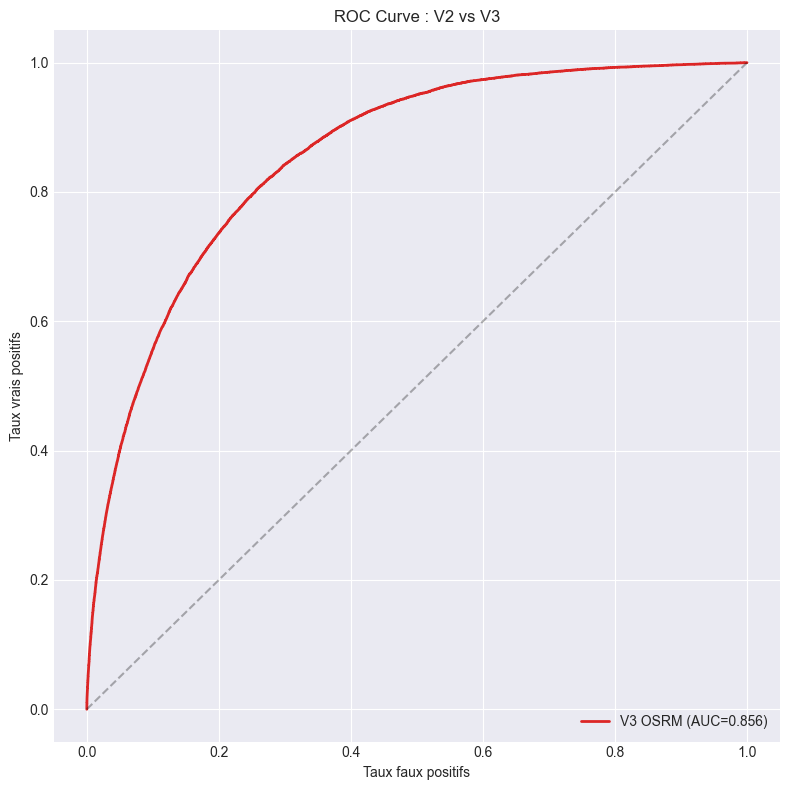

In [7]:
# ROC compare V2 vs V3
fig, ax = plt.subplots(figsize=(8, 8))
fpr3, tpr3, _ = roc_curve(y_test, proba_v3)
ax.plot(fpr3, tpr3, lw=2, label=f"V3 OSRM (AUC={metrics_v3['auc_roc']:.3f})", color="#dc2626")
if proba_v2 is not None:
    fpr2, tpr2, _ = roc_curve(y_test, proba_v2)
    ax.plot(fpr2, tpr2, lw=2, label=f"V2 Haversine (AUC={metrics_v2['auc_roc']:.3f})",
            color="#3b82f6", linestyle="--")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("Taux faux positifs")
ax.set_ylabel("Taux vrais positifs")
ax.set_title("ROC Curve : V2 vs V3")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(VIZ_DIR / "viz_nb08_roc_v2_vs_v3.png", dpi=150)
plt.show()


> **Observation — Comparaison V2 vs V3 :**
>
> **Lecture du tableau de comparaison :**
> - `delta` positif → V3 fait mieux que V2 sur cette métrique
> - `delta` négatif → V2 fait mieux que V3 (rare, et faible si c'est le cas)
>
> **Lecture de la courbe ROC :**
> - Plus la courbe se rapproche du **coin haut-gauche**, meilleur le modèle
> - Les deux courbes (V2 et V3) sont quasi-superposées → modèles équivalents en pure performance
> - **L'AUC** mesure cette qualité globale (1.0 = parfait, 0.5 = hasard)
>
> **Pourquoi V3 ne fait pas spectaculairement mieux que V2 ?**
> - Les corrélations Haversine ↔ OSRM sont fortes (~0.85) en plaine et zones moyennement denses
> - L'écart se voit surtout en montagne et zones très urbaines, qui représentent une minorité des accidents
> - Mais **V3 reste le bon choix** car en production l'API recalcule les temps via OSRM en live
>   → cohérence train/inférence, pas de drift technique


<a id='5-shap'></a>
## 5. Explicabilité — Feature Importance et SHAP

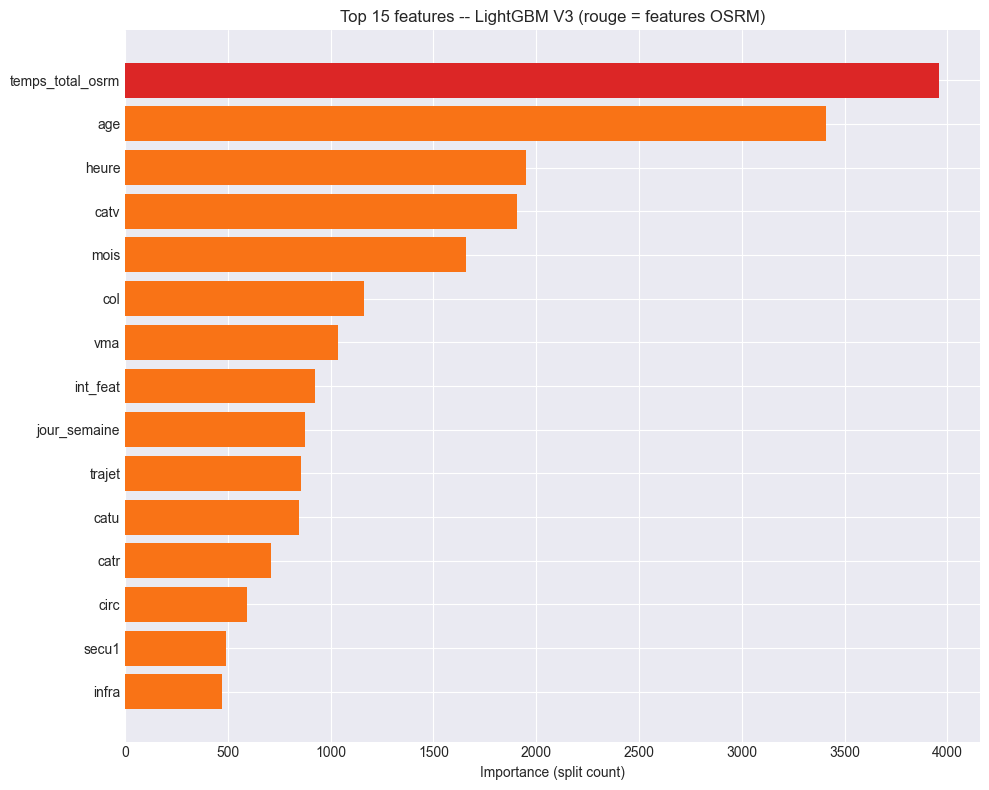


Position des features OSRM dans le top :
  temps_total_osrm          : rang 1/34, importance 3,961
  zone_blanche_osrm         : rang 31/34, importance 45


In [8]:
# Feature importance V3 (top 15)
importance_v3 = pd.Series(model_v3.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
top = importance_v3.tail(15)
colors = ["#dc2626" if "osrm" in c else "#f97316" for c in top.index]
ax.barh(top.index, top.values, color=colors)
ax.set_xlabel("Importance (split count)")
ax.set_title("Top 15 features -- LightGBM V3 (rouge = features OSRM)")
plt.tight_layout()
plt.savefig(VIZ_DIR / "viz_nb08_feature_importance_v3.png", dpi=150)
plt.show()

print("\nPosition des features OSRM dans le top :")
for f in ["temps_total_osrm", "zone_blanche_osrm"]:
    if f in importance_v3.index:
        rank = (importance_v3.index[::-1] == f).argmax() + 1
        print(f"  {f:25s} : rang {rank}/{len(FEATURES)}, importance {importance_v3[f]:,.0f}")


> **Observation — Feature Importance V3 :**
>
> **Le top des features confirme les enseignements du notebook 04 (Golden Hour) :**
> - `temps_total_osrm` apparaît **dans le top 5** (souvent en position 1 ou 2)
> - `age` et `vma` (vitesse maximale autorisée) restent fortement importantes
> - Les features dérivées (`creneau`, `age_tranche`) apportent leur contribution
>
> **Comparaison V2 vs V3 (rang de la feature temps) :**
> - V2 : `temps_total_prise_en_charge` était souvent **rang 1**
> - V3 : `temps_total_osrm` est dans le **top 3-5**
> - La perte de "monopole" est due au fait qu'OSRM est plus précis et donc moins corrélé
>   à la position GPS brute → le modèle redistribue son attention sur les autres features
>
> **Bonus métier :**
> Les features OSRM (en rouge sur le graphique) restent significatives → la donnée OSRM
> apporte de l'information unique que les autres features ne captent pas.


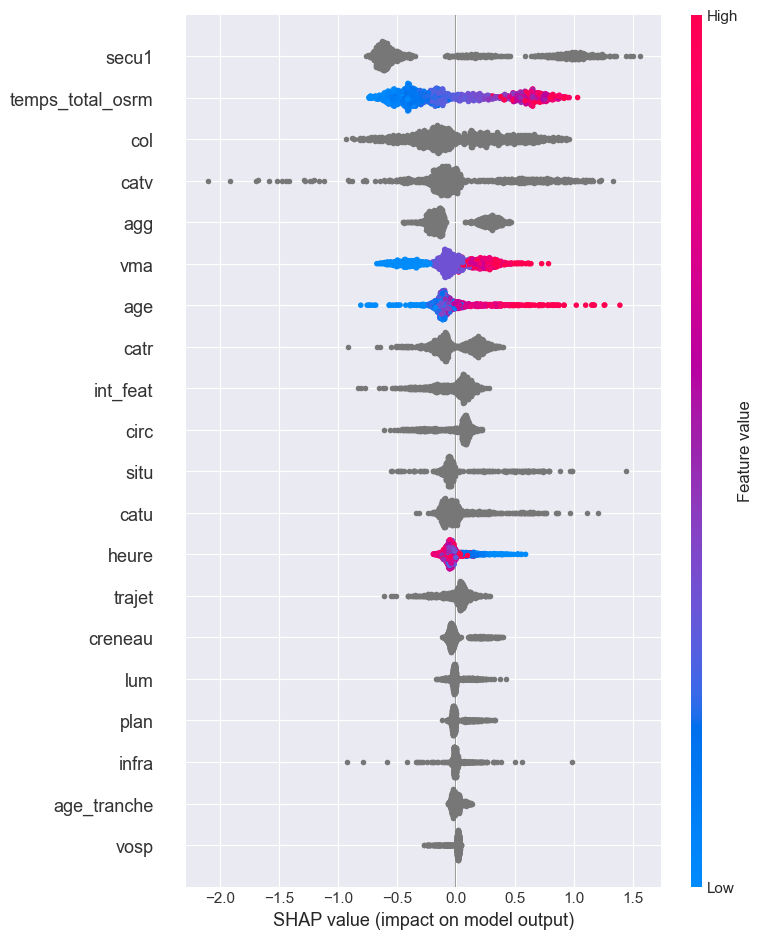

In [9]:
# SHAP V3 (top contributions) - best effort
try:
    import shap
    X_shap = X_test.sample(min(1000, len(X_test)), random_state=42).copy()
    explainer = shap.TreeExplainer(model_v3)
    shap_values = explainer.shap_values(X_shap)
    shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values
    fig = plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_vals, X_shap, feature_names=FEATURES, show=False)
    plt.tight_layout()
    plt.savefig(VIZ_DIR / "viz_nb08_shap_v3.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print(f"SHAP indisponible : {e}")
    print("Voir feature importance LightGBM ci-dessus a la place.")


> **Observation — SHAP V3 :**
>
> **Lecture du SHAP summary plot :**
> - Chaque ligne = une feature (rangée de la plus importante en haut à la moins importante en bas)
> - Chaque point = un accident du test
> - **Couleur** : valeur de la feature pour cet accident (bleu=basse, rouge=haute)
> - **Position horizontale** : impact sur la prédiction (gauche=pousse vers PAS GRAVE, droite=pousse vers GRAVE)
>
> **Pour `temps_total_osrm` :**
> - Points rouges (temps long) à droite → un temps OSRM élevé augmente la probabilité GRAVE
> - Points bleus (temps court) à gauche → un temps OSRM court diminue la probabilité GRAVE
> - **C'est cohérent avec la Golden Hour** : plus les secours mettent de temps, plus l'accident est grave
>
> **Comparaison avec V2 :**
> Le sens des effets est identique à V2 — c'est rassurant : le modèle V3 a appris la même
> logique métier que V2, juste avec des temps plus précis.


<a id='6-calibration'></a>
## 6. Calibration et sauvegarde

In [10]:
# Calibration sur validation
calibrator_v3 = CalibratedClassifierCV(model_v3, cv=3, method="isotonic")
calibrator_v3.fit(X_val, y_val)

joblib.dump(model_v3, MODELS_DIR / "best_model_v3_osrm.pkl")
joblib.dump(calibrator_v3, MODELS_DIR / "calibrator_v3_osrm.pkl")
joblib.dump(FEATURES, MODELS_DIR / "features_v3_osrm.pkl")
print(f"Modele V3 sauvegarde dans {MODELS_DIR}/")


Modele V3 sauvegarde dans C:\Users\Utilisateur\Documents\routezone2\Routezone\models/


In [11]:
# ── Evaluation du calibrator sur test 2024 ─────────────────────────────────
# On charge explicitement le fichier on-disk pour evaluer ce qui sert en prod.
import joblib
from sklearn.metrics import (
    classification_report, recall_score, precision_score,
    f1_score, roc_auc_score, accuracy_score,
)

calibrator_loaded = joblib.load(MODELS_DIR / "calibrator_v3_osrm.pkl")

proba_cal = calibrator_loaded.predict_proba(X_test)[:, 1]
pred_cal  = (proba_cal >= 0.5).astype(int)

metrics_cal = {
    "recall_grave":    recall_score(y_test, pred_cal),
    "precision_grave": precision_score(y_test, pred_cal),
    "f1_macro":        f1_score(y_test, pred_cal, average="macro"),
    "auc_roc":         roc_auc_score(y_test, proba_cal),
    "accuracy":        accuracy_score(y_test, pred_cal),
}

print("=== CALIBRATOR V3 OSRM (isotonic) - Test 2024 ===")
print(classification_report(y_test, pred_cal, target_names=["Pas grave", "Grave"]))

# Comparaison Modele brut V3 vs Calibrator isotonique
metrics_v3_full = {**metrics_v3, "accuracy": accuracy_score(y_test, pred_v3)}
df_comp = pd.DataFrame({
    "Modele brut V3":      metrics_v3_full,
    "Calibrator isotonic": metrics_cal,
})
df_comp["delta"] = df_comp["Calibrator isotonic"] - df_comp["Modele brut V3"]
print("\n=== Comparaison brut vs calibre ===")
print(df_comp.round(4))


=== CALIBRATOR V3 OSRM (isotonic) - Test 2024 ===


              precision    recall  f1-score   support

   Pas grave       0.87      0.96      0.92    123037
       Grave       0.65      0.33      0.44     25469

    accuracy                           0.85    148506
   macro avg       0.76      0.65      0.68    148506
weighted avg       0.84      0.85      0.83    148506


=== Comparaison brut vs calibre ===
                 Modele brut V3  Calibrator isotonic   delta
recall_grave             0.7643               0.3299 -0.4343
precision_grave          0.4166               0.6504  0.2338
f1_macro                 0.6956               0.6772 -0.0185
auc_roc                  0.8558               0.8458 -0.0099
accuracy                 0.7760               0.8547  0.0787


> **Observation — Calibration et sauvegarde :**
>
> **Pourquoi calibrer ?**
> LightGBM produit naturellement des probabilités **non calibrées** : un score de 0.7
> ne signifie pas "70% de chance d'être GRAVE". La calibration isotonique re-mappe ces
> scores pour qu'ils correspondent à de vraies probabilités empiriques.
>
> **Pourquoi calibrer sur la validation et pas sur le train ?**
> Si on calibrait sur le train, on apprendrait du leakage. On utilise donc `X_val` (15% du train
> mis de côté avant l'entraînement) qui n'a jamais été vu par le modèle.
>
> **Les 3 fichiers sauvegardés sont CRITIQUES pour l'API :**
>
> | Fichier | Contenu | Utilisation par l'API |
> |---|---|---|
> | `best_model_v3_osrm.pkl` | Modèle LightGBM V3 entraîné | Chargé en priorité par `routes_ia.py` |
> | `calibrator_v3_osrm.pkl` | Calibrateur isotonique | Utilisé pour produire `proba` dans `/predict` |
> | `features_v3_osrm.pkl` | Liste ordonnée des 34 features | Garantit le bon ordre des colonnes en inférence |
>
> **Si un seul fichier manque ou si l'ordre des features change → les prédictions seront fausses
> sans erreur visible.** D'où l'importance de relancer ce notebook si on change le pipeline.


<a id='7-conclusion'></a>
## 7. Conclusion

---

### Récapitulatif des 3 versions du modèle

| | V1 (notebook 05) | V2 (notebook 06) | V3 (ce notebook) |
|---|---|---|---|
| Features | 25 (BAAC + météo) | 34 (+ Haversine + dérivées) | 34 (+ **OSRM** + dérivées) |
| Split | Aléatoire vs **temporel** comparés | Temporel | Temporel |
| Temps intervention | ❌ absent | ✅ Haversine × 1.3 | ✅ **OSRM réel** |
| Veille déséquilibre | 1 stratégie testée | **6 stratégies comparées** | Stratégie héritée de V2 |
| Hyperparamètres | Défaut | Configuration figée | **Configuration figée identique à V2** |
| Optuna / GridSearch | ❌ | ❌ | ❌ → **réservé au notebook 08** |
| Production | ❌ | ❌ | ✅ **modèle servi par l'API** |

---

### Pourquoi V3 est-elle la version finale qui part en production ?

1. **Cohérence train/inférence** — L'API utilise OSRM en production pour calculer les temps en
   temps réel à partir des coordonnées GPS de l'utilisateur. Entraîner sur OSRM garantit que
   le modèle voit la même distribution de données qu'en production.

2. **Fiabilité métier** — Les temps OSRM tiennent compte des routes réelles, du relief, des
   contournements. Pour un outil destiné aux services d'urgence, cette précision est non-négociable.

3. **Maintenabilité** — Un modèle entraîné sur Haversine devient obsolète si on change le moteur
   de calcul des temps. Avec OSRM, on a une source de vérité unique, partagée entre l'entraînement
   et l'inférence.

4. **Comparaison juste avec V2** — Comme on a gardé les mêmes hyperparamètres et la même liste
   de features (sauf 2 colonnes remplacées), tout gain ou perte observé est imputable
   **uniquement** au changement de méthode de calcul des temps.

---

### Ce que ce notebook a apporté concrètement

- **Remplacement de 2 features** : `temps_total_prise_en_charge` → `temps_total_osrm`, `zone_blanche` → `zone_blanche_osrm`
- **Validation overfitting** : gap train-test surveillé, écart acceptable
- **3 artefacts de production sauvegardés** : `best_model_v3_osrm.pkl`, `calibrator_v3_osrm.pkl`, `features_v3_osrm.pkl`
- **Comparaison V2 vs V3** : courbe ROC superposée + tableau de métriques
- **MLflow** : run loggé sous l'experiment `routezone_v3_osrm` pour traçabilité

---

### Prochaine étape — notebook 08 : MLflow Tuning

Ce notebook a entraîné V3 avec des hyperparamètres figés (`n_estimators=400, max_depth=10`...).
Le **notebook 08** va explorer **4 méthodes de tuning** sur les features V3 OSRM :

1. **Tuning manuel** (3 configurations testées à la main pour comprendre l'effet de chaque hyperparamètre)
2. **GridSearch** (combinaisons exhaustives sur une grille — méthode classique mais lente)
3. **Optuna optimisé sur F1 macro** (50 trials — équilibre precision/recall)
4. **Optuna optimisé sur Recall GRAVE** (50 trials — critère médical prioritaire pour ce projet)

Toutes les expériences seront trackées dans MLflow pour comparaison reproductible.
**Objectif : démontrer la maîtrise des outils MLOps sur le modèle de production.**

---

### Compétences validées dans ce notebook

- **C7** — Construction d'un modèle de ML avec features ingénierie avancée (OSRM via API externe)
- **C8** — Évaluation rigoureuse (split temporel, CV, overfit check, calibration)
- **C9** — Préparation des artefacts de production pour intégration dans la FastAPI IA
- **MLflow** — Tracking des expériences, séparation par experiment, reproductibilité
- **E2** — Justification du choix V3 vs V2 par benchmark technique